In [ ]:
import numpy as np
import pandas as pd

In [53]:
# задача 3.1 - линейный штраф за гэп
def needleman_wunsch(s1, s2, match, mismatch, gap):
    n = len(s1)
    m = len(s2)
    matrix = np.zeros((n+1, m+1))


    for k in range (n+1):
        matrix[k][0] = gap * k
    for k in range (m + 1):
        matrix[0][k] = gap * k
        
    for i in range(1, n+1):
        for j in range(1, m+1):
            score = match if s1[i-1]== s2[j-1] else mismatch
            up = matrix[i-1][j] + gap
            diag = matrix[i-1][j-1] + score
            left = matrix[i][j-1] + gap
            matrix[i][j] = max(up, diag, left)

    # traceback
    align1 = ""
    align2 = ""
    i, j = n, m
    while i > 0 and j > 0:
        if matrix[i][j] == matrix[i-1][j-1] + (match if s1[i-1]== s2[j-1] else mismatch):
            align1 = s1[i-1] + align1
            align2 = s2[j-1] +align2
            i -= 1
            j -= 1
        elif matrix[i][j] == matrix[i-1][j] + gap:
            align1 = s1[i-1] + align1
            align2 = "-" + align2
            i -= 1
        elif matrix[i][j] == matrix[i][j-1] + gap:
            align1 = "-" + align1
            align2 = s2[j-1] + align2
            j -= 1
    score = matrix[n][m]
    print(align1)
    print(align2)
    print(score)
    print(pd.DataFrame(matrix))
            
        
    
            

In [54]:
needleman_wunsch("ATATAT", "ATGCAGCAGCAGCCA",4, -4, -4)


AT-----A-TA---T
ATGCAGCAGCAGCCA
-28.0
     0     1    2     3     4     5     6     7     8     9     10    11  \
0   0.0  -4.0 -8.0 -12.0 -16.0 -20.0 -24.0 -28.0 -32.0 -36.0 -40.0 -44.0   
1  -4.0   4.0  0.0  -4.0  -8.0 -12.0 -16.0 -20.0 -24.0 -28.0 -32.0 -36.0   
2  -8.0   0.0  8.0   4.0   0.0  -4.0  -8.0 -12.0 -16.0 -20.0 -24.0 -28.0   
3 -12.0  -4.0  4.0   4.0   0.0   4.0   0.0  -4.0  -8.0 -12.0 -16.0 -20.0   
4 -16.0  -8.0  0.0   0.0   0.0   0.0   0.0  -4.0  -8.0 -12.0 -16.0 -20.0   
5 -20.0 -12.0 -4.0  -4.0  -4.0   4.0   0.0  -4.0   0.0  -4.0  -8.0 -12.0   
6 -24.0 -16.0 -8.0  -8.0  -8.0   0.0   0.0  -4.0  -4.0  -4.0  -8.0 -12.0   

     12    13    14    15  
0 -48.0 -52.0 -56.0 -60.0  
1 -40.0 -44.0 -48.0 -52.0  
2 -32.0 -36.0 -40.0 -44.0  
3 -24.0 -28.0 -32.0 -36.0  
4 -24.0 -28.0 -32.0 -36.0  
5 -16.0 -20.0 -24.0 -28.0  
6 -16.0 -20.0 -24.0 -28.0  


In [68]:
# задание 3.2 - афинный штраф за гэп

def needleman_wunsch_affine(s1, s2, match, mismatch, open_gap, extend_gap):
    n, m = len(s1), len(s2)
    
    # Три матрицы для трёх состояний
    M = np.full((n+1, m+1), -np.inf)  # совпадение/несовпадение
    X = np.full((n+1, m+1), -np.inf)  # гэп в первой последовательности (по X)
    Y = np.full((n+1, m+1), -np.inf)  # гэп во второй последовательности (по Y)
    
    # Матрица для обратного хода (0=M, 1=X, 2=Y)
    trace = np.zeros((n+1, m+1, 3), dtype=int)
    
    # Начальные условия
    M[0][0] = 0
    X[0][0] = -np.inf
    Y[0][0] = -np.inf
    
    # Инициализация первой строки и столбца
    for i in range(1, n+1):
        M[i][0] = -np.inf
        X[i][0] = -np.inf
        Y[i][0] = open_gap + (i-1) * extend_gap
        trace[i][0] = [0, 0, 1]  # из Y
        
    for j in range(1, m+1):
        M[0][j] = -np.inf
        X[0][j] = open_gap + (j-1) * extend_gap
        Y[0][j] = -np.inf
        trace[0][j] = [0, 1, 0]  # из X
    
    # Заполнение матриц
    for i in range(1, n+1):
        for j in range(1, m+1):
            score = match if s1[i-1] == s2[j-1] else mismatch
            
            # M[i][j] — пришли по диагонали
            candidates = [
                M[i-1][j-1] + score,
                X[i-1][j-1] + score,
                Y[i-1][j-1] + score
            ]
            M[i][j] = max(candidates)
            trace[i][j][0] = np.argmax(candidates)  # откуда пришли в M
            
            # X[i][j] — гэп в X (в первой последовательности)
            candidates = [
                M[i-1][j] + open_gap,
                X[i-1][j] + extend_gap,
                Y[i-1][j] + open_gap
            ]
            X[i][j] = max(candidates)
            trace[i][j][1] = np.argmax(candidates)  # откуда пришли в X
            
            # Y[i][j] — гэп в Y (во второй последовательности)
            candidates = [
                M[i][j-1] + open_gap,
                X[i][j-1] + open_gap,
                Y[i][j-1] + extend_gap
            ]
            Y[i][j] = max(candidates)
            trace[i][j][2] = np.argmax(candidates)  # откуда пришли в Y
    
    # Итоговый счёт
    final_score = max(M[n][m], X[n][m], Y[n][m])
    if final_score == M[n][m]:
        state = 0
    elif final_score == X[n][m]:
        state = 1
    else:
        state = 2
    
    # traceback
    align1, align2 = "", ""
    i, j = n, m
    
    while i > 0 or j > 0:
        if state == 0:  # M — совпадение/несовпадение
            if i > 0 and j > 0:
                align1 = s1[i-1] + align1
                align2 = s2[j-1] + align2
            prev_state = trace[i][j][0]
            i -= 1
            j -= 1
        elif state == 1:  # X — гэп в X
            if i > 0:
                align1 = s1[i-1] + align1
                align2 = "-" + align2
            prev_state = trace[i][j][1]
            i -= 1
        else:  
            # state == 2 — гэп в Y
            if j > 0:
                align1 = "-" + align1
                align2 = s2[j-1] + align2
            prev_state = trace[i][j][2]
            j -= 1
        state = prev_state
    

    print(align1)
    print(align2)
    print(final_score)




In [69]:
needleman_wunsch_affine("ATATAT", "ATGCAGCAGCAGCCA",3, -3, -10, -1)

ATATA---------T
ATGCAGCAGCAGCCA
-18.0


В аффинной модели явно видно, что это не просто случайное совпадение, а действительно части последовательностей гомологичны.

In [70]:
# задание 4

match = 3
mismatch = -3
gap = -2
k = 4
X = 2

ref   = "CTAGGATCCAGGCATACGA"
query = "GGATCCATTCATTA"


def s(a, b):
    return match if a == b else mismatch



# индекс референса
index = {}
for i in range(len(ref) - k + 1):
    kmer = ref[i:i+k]
    index.setdefault(kmer, []).append(i)

print("Индекс БД:")
for kmer, positions in sorted(index.items()):
    print(f"  {kmer}: {positions}")


# поиск seed'ов
seeds = []
for i in range(len(query) - k + 1):
    kmer = query[i:i+k]
    if kmer in index:
        for j in index[kmer]:
            seeds.append((i, j, kmer))

print("\nНайденные seed'ы (query_pos, ref_pos, kmer):")
for seed in seeds:
    print(f"  query[{seed[0]}:{seed[0]+k}] = ref[{seed[1]}:{seed[1]+k}] = {seed[2]}")


# расширение
def extend(q_start, r_start, q_end, r_end):
    """
    Расширяем влево от q_start/r_start и вправо от q_end/r_end.
    Возвращаем (smax, best_q_start, best_r_start, best_q_end, best_r_end,
                left_scores, right_scores)
    """
    seed_score = k * match  # seed совпал идеально

    # расширение влево
    left_scores = []
    scur = seed_score
    smax = seed_score
    best_left_q = q_start
    best_left_r = r_start

    qi, ri = q_start - 1, r_start - 1
    while qi >= 0 and ri >= 0:
        scur += s(query[qi], ref[ri])
        left_scores.append((qi, ri, scur))
        if scur > smax:
            smax = scur
            best_left_q = qi
            best_left_r = ri
        if smax - scur >= X:
            break
        qi -= 1
        ri -= 1

    # расширение вправо
    right_scores = []
    scur = smax  # продолжаем от лучшего значения после левого расширения
    best_right_q = q_end
    best_right_r = r_end

    qi, ri = q_end, r_end
    while qi < len(query) and ri < len(ref):
        scur += s(query[qi], ref[ri])
        right_scores.append((qi, ri, scur))
        if scur > smax:
            smax = scur
            best_right_q = qi + 1
            best_right_r = ri + 1
        if smax - scur >= X:
            break
        qi += 1
        ri += 1

    return smax, best_left_q, best_left_r, best_right_q, best_right_r, left_scores, right_scores


# запускаем расширение для каждого seed'а
best_smax = -1
best_result = None

for (qi, ri, kmer) in seeds:
    q_end = qi + k
    r_end = ri + k
    seed_score = k * match

    print(f"\nSeed: {kmer}  query[{qi}:{q_end}]  ref[{ri}:{r_end}]  seed_score={seed_score}")

    smax, blq, blr, brq, brr, left_sc, right_sc = extend(qi, ri, q_end, r_end)

    print(f"  Расширение влево:")
    if left_sc:
        for (q, r, sc) in left_sc:
            print(f"    query[{q}]={query[q]} vs ref[{r}]={ref[r]}  Scur={sc}")
    else:
        print("    некуда расширяться")

    print(f"  Расширение вправо:")
    if right_sc:
        for (q, r, sc) in right_sc:
            print(f"    query[{q}]={query[q]} vs ref[{r}]={ref[r]}  Scur={sc}")
    else:
        print("    некуда расширяться")

    print(f"  Smax = {smax}")
    print(f"  Итоговый регион: query[{blq}:{brq}]  ref[{blr}:{brr}]")
    print(f"    query: {query[blq:brq]}")
    print(f"    ref:   {ref[blr:brr]}")

    if smax > best_smax:
        best_smax = smax
        best_result = (kmer, blq, blr, brq, brr)

print("Лучший результат:")
kmer, blq, blr, brq, brr = best_result
print(f"  Лучший k-мер: {kmer}")
print(f"  Smax = {best_smax}")
q_aligned = query[blq:brq]
r_aligned = ref[blr:brr]
print(f"  Query: {q_aligned}")
match_str = "".join("|" if a == b else "." for a, b in zip(q_aligned, r_aligned))
print(f"         {match_str}")
print(f"  Ref:   {r_aligned}")

Индекс БД:
  ACGA: [15]
  AGGA: [2]
  AGGC: [9]
  ATAC: [13]
  ATCC: [5]
  CAGG: [8]
  CATA: [12]
  CCAG: [7]
  CTAG: [0]
  GATC: [4]
  GCAT: [11]
  GGAT: [3]
  GGCA: [10]
  TACG: [14]
  TAGG: [1]
  TCCA: [6]

Найденные seed'ы (query_pos, ref_pos, kmer):
  query[0:4] = ref[3:7] = GGAT
  query[1:5] = ref[4:8] = GATC
  query[2:6] = ref[5:9] = ATCC
  query[3:7] = ref[6:10] = TCCA

Seed: GGAT  query[0:4]  ref[3:7]  seed_score=12
  Расширение влево:
    некуда расширяться
  Расширение вправо:
    query[4]=C vs ref[7]=C  Scur=15
    query[5]=C vs ref[8]=C  Scur=18
    query[6]=A vs ref[9]=A  Scur=21
    query[7]=T vs ref[10]=G  Scur=18
  Smax = 21
  Итоговый регион: query[0:7]  ref[3:10]
    query: GGATCCA
    ref:   GGATCCA

Seed: GATC  query[1:5]  ref[4:8]  seed_score=12
  Расширение влево:
    query[0]=G vs ref[3]=G  Scur=15
  Расширение вправо:
    query[5]=C vs ref[8]=C  Scur=18
    query[6]=A vs ref[9]=A  Scur=21
    query[7]=T vs ref[10]=G  Scur=18
  Smax = 21
  Итоговый регион: query

In [22]:
# задание 5
from Bio import Entrez, SeqIO

Entrez.email = "semeno.ma@phystech.edu"

def fetch_mitochondrion(accession):
    """Скачивает и возвращает митохондриальный геном"""
    
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="fasta")
    
    # Получаем запись
    record = SeqIO.read(handle, "fasta")
    handle.close()  
    
    return record.seq
human_seq = fetch_mitochondrion("NC_012920.1")
neand_seq = fetch_mitochondrion("NC_011137.1")
                      


In [40]:
def dot_plot(seq1, seq2, window, threshold, step):
    x = []
    y = []
    for i in range(0, len(seq1)-window+1, step):
        s1 = seq1[i:(i+window)]
        for j in range(0, len(seq2)-window+1, step):
            match = 0
            s2 = seq2[j : (j + window)]
            for k in range(window):
                if s1[k] == s2[k]:
                    match += 1
            if match / window >= threshold:
                plt.plot(i, j, "o")
    plt.xlabel("human")
    plt.ylabel("neanderthal")
    plt.show()

/tmp/ipykernel_3595/3052469822.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


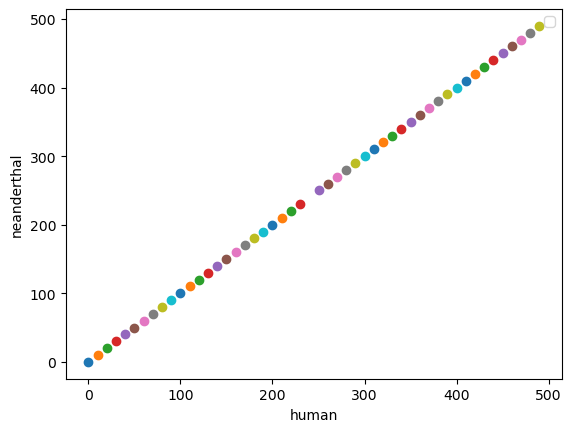

In [41]:
dot_plot(human_seq, neand_seq, 30, 0.9, 10)

Вывод: На графике наблюдается непрерывная диагональная линия, что свидетельствует о том, что гены в геномах расположены в одинаковом порядке и мутации редки. 
Наблюдаются некоторые разрывы, что может свидетельствовать о наличии точечных мутаций в некоторых генах